In [3]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

df = pd.read_csv('../dataset/featured_btc_data.csv.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# split
from sklearn.model_selection import train_test_split

X = df[['lag1', 'lag2', 'lag3', 'ma7', 'ma30', 'volatility']]
y = df['close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [5]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 936.9048242455491


In [7]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 1339.2416129198193


In [9]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9978096552214503


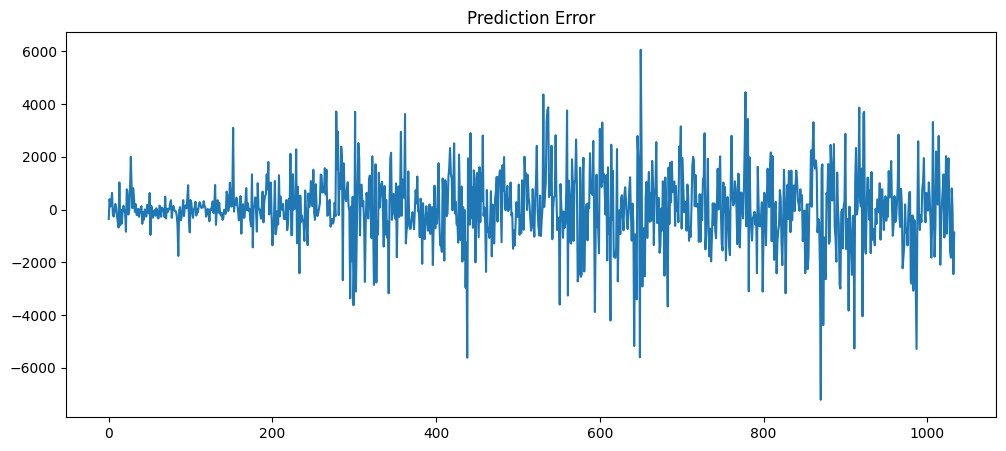

In [ ]:
#Visualisasi Eror
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values - y_pred)
plt.title("Prediction Error")
plt.show()